<a href="https://colab.research.google.com/github/Ajitgupta31/Machine_Learning/blob/main/IPL_Match_Scores_Analysis_with_Matplotlib_Project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## IPL Match Scores Analysis with Matplotlib

This notebook will demonstrate how to visualize IPL match scores using Matplotlib. We'll start by creating some dummy data, and then we'll generate various plots to analyze match outcomes, team performance, and more.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for better aesthetics
sns.set_style('whitegrid')

### Creating Sample IPL Match Data

Since no specific data was provided, we'll create a synthetic dataset to simulate IPL match results. This dataset will include information like teams, scores, winners, and seasons.

In [ ]:
# Sample Data for IPL Matches
data = {
    'Match_ID': range(1, 21),
    'Season': ['2023'] * 10 + ['2024'] * 10,
    'Team1': [
        'MI', 'CSK', 'RCB', 'KKR', 'PBKS', 'RR', 'SRH', 'DC', 'MI', 'CSK',
        'RCB', 'KKR', 'PBKS', 'RR', 'SRH', 'DC', 'MI', 'CSK', 'RCB', 'KKR'
    ],
    'Team2': [
        'CSK', 'MI', 'PBKS', 'RR', 'RCB', 'KKR', 'DC', 'SRH', 'SRH', 'PBKS',
        'DC', 'MI', 'CSK', 'RCB', 'KKR', 'RR', 'PBKS', 'SRH', 'MI', 'DC'
    ],
    'Score1': [
        170, 180, 165, 190, 150, 175, 140, 160, 185, 170,
        155, 160, 195, 145, 170, 180, 165, 190, 150, 175
    ],
    'Score2': [
        172, 178, 160, 188, 152, 170, 145, 158, 180, 173,
        150, 162, 190, 148, 168, 175, 168, 185, 153, 170
    ],
    'Winner': [
        'CSK', 'CSK', 'RCB', 'KKR', 'PBKS', 'RR', 'SRH', 'DC', 'MI', 'PBKS',
        'RCB', 'KKR', 'PBKS', 'RR', 'SRH', 'DC', 'PBKS', 'CSK', 'MI', 'KKR'
    ],
    'Venue': [
        'Wankhede', 'Chepauk', 'Chinnaswamy', 'Eden Gardens', 'Mohali', 'Jaipur', 'Hyderabad', 'Delhi',
        'Wankhede', 'Chepauk', 'Chinnaswamy', 'Eden Gardens', 'Mohali', 'Jaipur', 'Hyderabad', 'Delhi',
        'Wankhede', 'Chepauk', 'Chinnaswamy', 'Eden Gardens'
    ]
}

df = pd.DataFrame(data)

# Calculate winning margin
df['Winning_Margin'] = abs(df['Score1'] - df['Score2'])

df.head()

,Match_ID,Season,Team1,Team2,Score1,Score2,Winner,Venue,Winning_Margin
0,1,2023,MI,CSK,170,172,CSK,Wankhede,2
1,2,2023,CSK,MI,180,178,CSK,Chepauk,2
2,3,2023,RCB,PBKS,165,160,RCB,Chinnaswamy,5
3,4,2023,KKR,RR,190,188,KKR,Eden Gardens,2
4,5,2023,PBKS,RCB,150,152,PBKS,Mohali,2


### 1. Matches Won by Each Team

Let's start by visualizing which teams have won the most matches. This will give us an initial insight into team performance.

/tmp/ipykernel_12322/1770423584.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=winner_counts.index, y=winner_counts.values, palette='viridis')


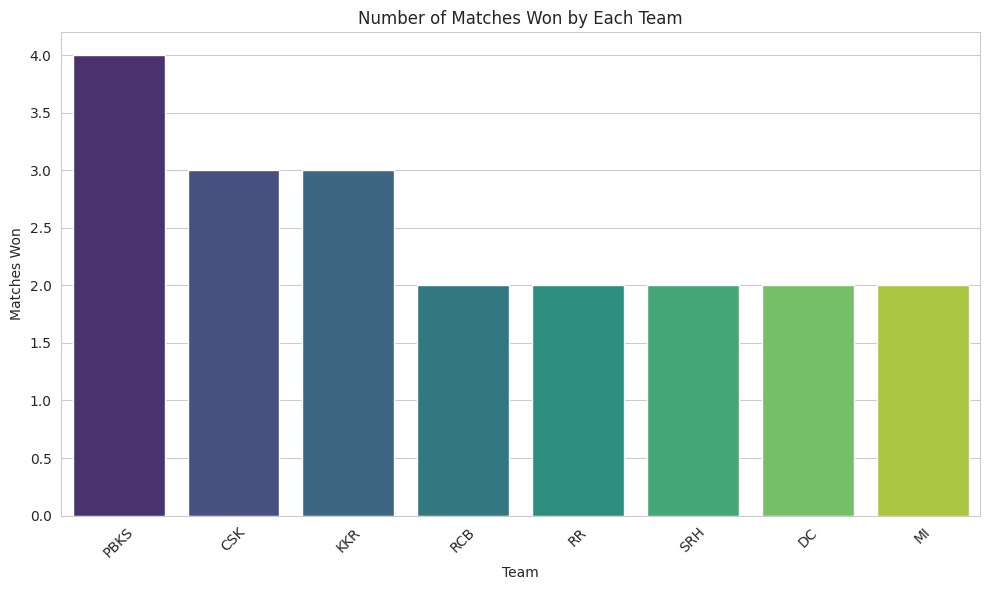

In [ ]:
winner_counts = df['Winner'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=winner_counts.index, y=winner_counts.values, palette='viridis')
plt.title('Number of Matches Won by Each Team')
plt.xlabel('Team')
plt.ylabel('Matches Won')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2. Distribution of Winning Margins

Understanding the distribution of winning margins can show us how competitive the matches typically are. We'll use a histogram for this.

/tmp/ipykernel_12322/1980615153.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df['Winning_Margin'], bins=5, kde=True, palette='viridis')


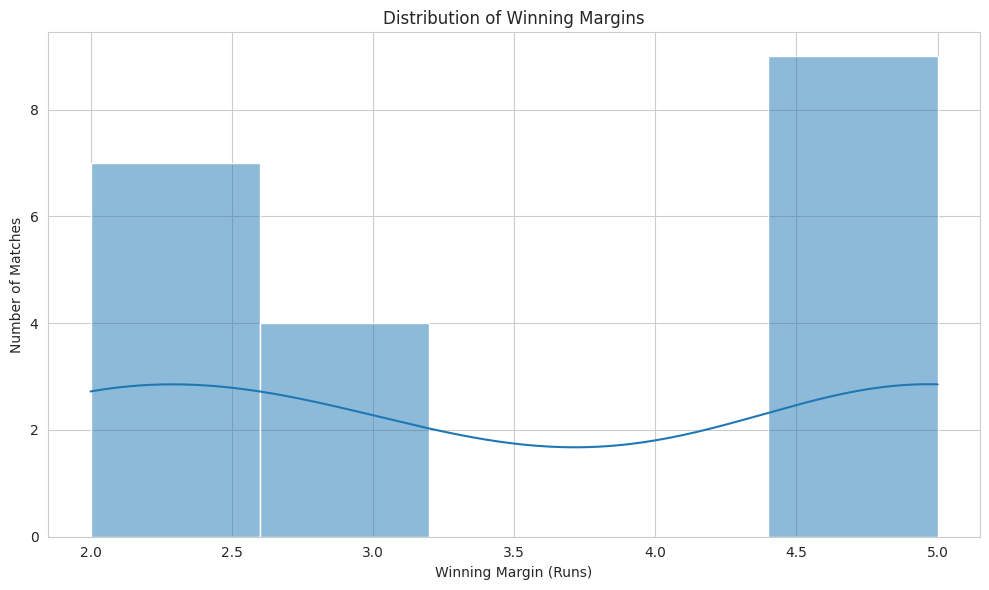

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Winning_Margin'], bins=5, kde=True, palette='viridis')
plt.title('Distribution of Winning Margins')
plt.xlabel('Winning Margin (Runs)')
plt.ylabel('Number of Matches')
plt.tight_layout()
plt.show()

### 3. Top Teams by Wins per Season

Let's analyze which team won the most matches in each season. This can highlight consistent performers or shifting dominance over time.

<Figure size 1200x700 with 0 Axes>

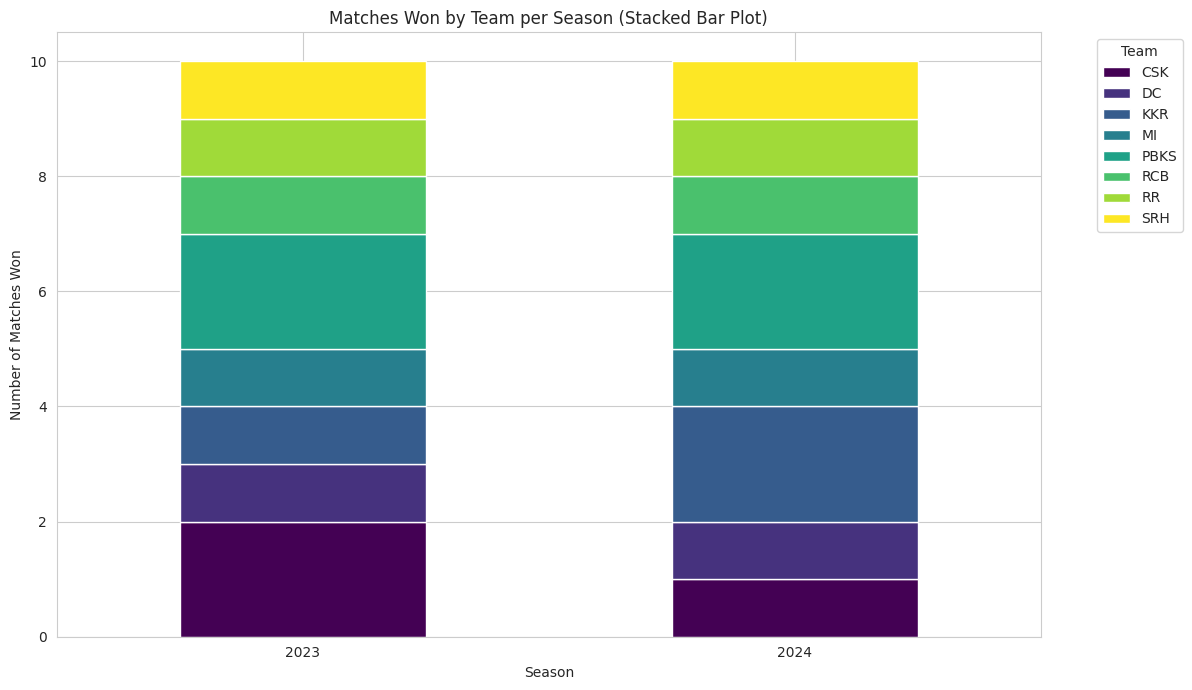

In [ ]:
seasonal_winners = df.groupby(['Season', 'Winner']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 7))
seasonal_winners.plot(kind='bar', stacked=True, colormap='viridis', figsize=(12, 7))
plt.title('Matches Won by Team per Season (Stacked Bar Plot)')
plt.xlabel('Season')
plt.ylabel('Number of Matches Won')
plt.xticks(rotation=0)
plt.legend(title='Team', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 4. Team Performance by Venue

Let's investigate if certain teams perform better at specific venues. This can reveal home-ground advantages or preferred playing conditions.

<Figure size 1400x800 with 0 Axes>

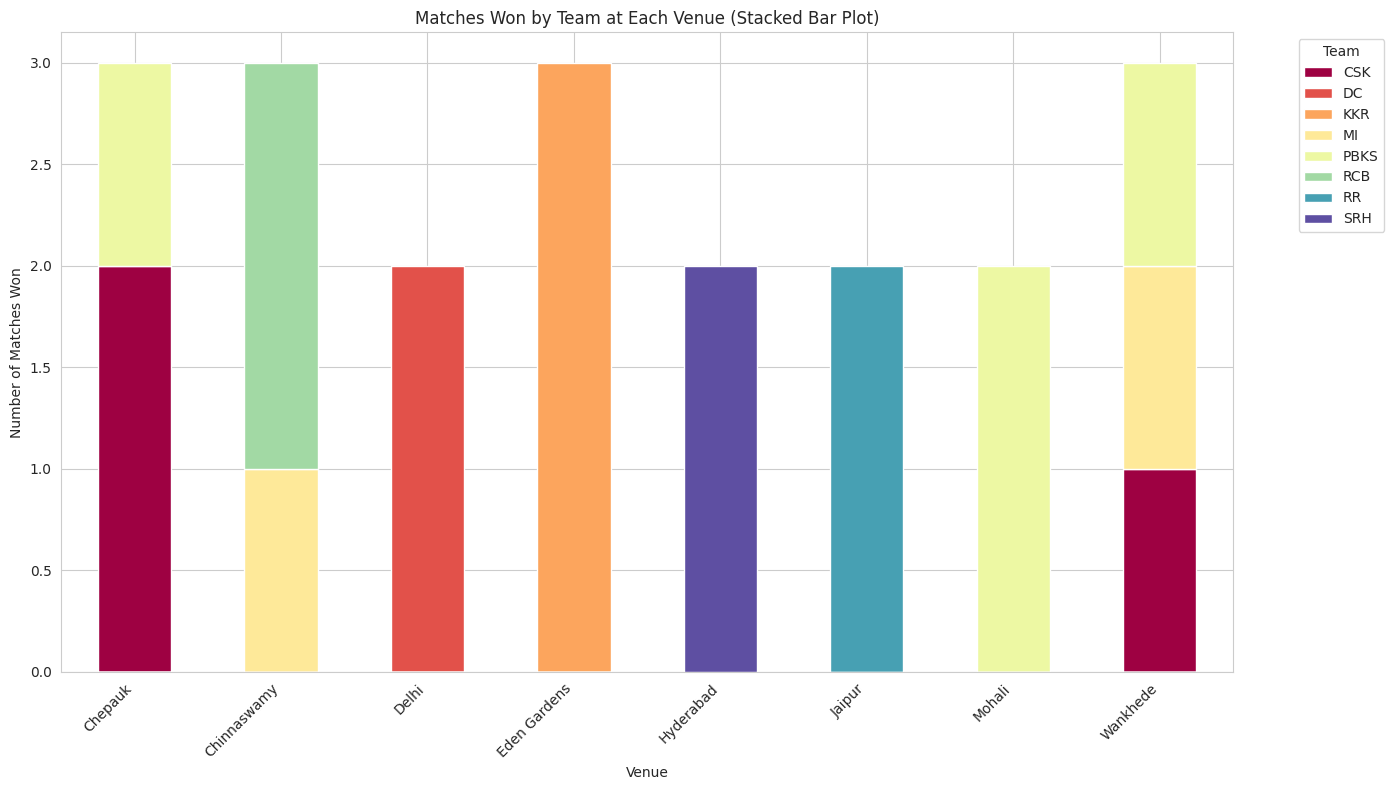

In [ ]:
venue_wins = df.groupby(['Venue', 'Winner']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 8))
venue_wins.plot(kind='bar', stacked=True, colormap='Spectral', figsize=(14, 8))
plt.title('Matches Won by Team at Each Venue (Stacked Bar Plot)')
plt.xlabel('Venue')
plt.ylabel('Number of Matches Won')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Team', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 5. Average Scores at Each Venue

Let's analyze the average scores (both Score1 and Score2 combined) at each venue to understand if some venues are typically high-scoring or low-scoring.

/tmp/ipykernel_12322/2494875764.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_scores_venue.index, y=average_scores_venue.values, palette='coolwarm')


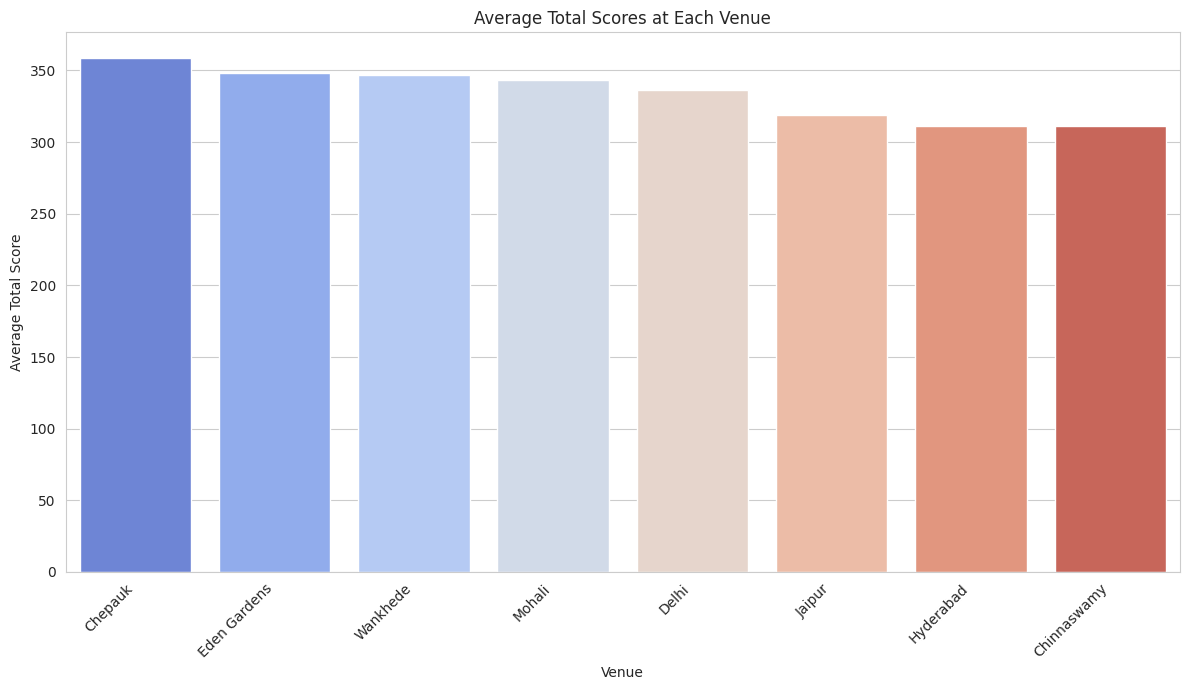

In [ ]:
df['Total_Score'] = df['Score1'] + df['Score2']

average_scores_venue = df.groupby('Venue')['Total_Score'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=average_scores_venue.index, y=average_scores_venue.values, palette='coolwarm')
plt.title('Average Total Scores at Each Venue')
plt.xlabel('Venue')
plt.ylabel('Average Total Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 6. Score Distribution for Winning and Losing Teams

Let's analyze the score distribution for both winning and losing teams to see if there's a clear difference in typical scores.

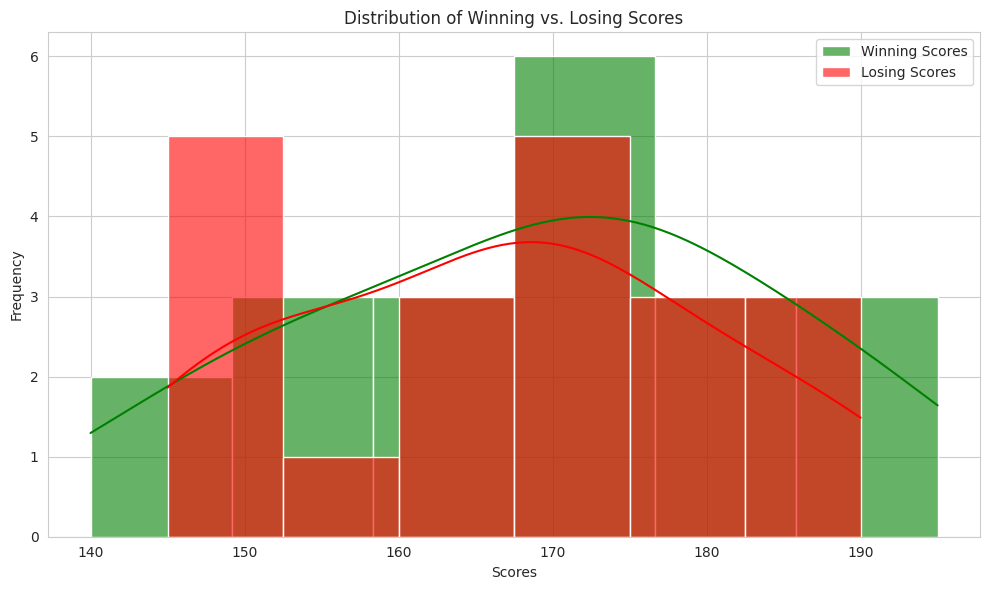

In [ ]:
winning_scores = []
losing_scores = []

for index, row in df.iterrows():
    if row['Winner'] == row['Team1']:
        winning_scores.append(row['Score1'])
        losing_scores.append(row['Score2'])
    else:
        winning_scores.append(row['Score2'])
        losing_scores.append(row['Score1'])

plt.figure(figsize=(10, 6))
sns.histplot(winning_scores, color='green', kde=True, label='Winning Scores', alpha=0.6)
sns.histplot(losing_scores, color='red', kde=True, label='Losing Scores', alpha=0.6)
plt.title('Distribution of Winning vs. Losing Scores')
plt.xlabel('Scores')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

### 7. Relationship Between Total Score and Winning Margin

Let's visualize if there's a correlation between the total runs scored in a match and the winning margin. This can help understand if high-scoring games are more or less competitive.

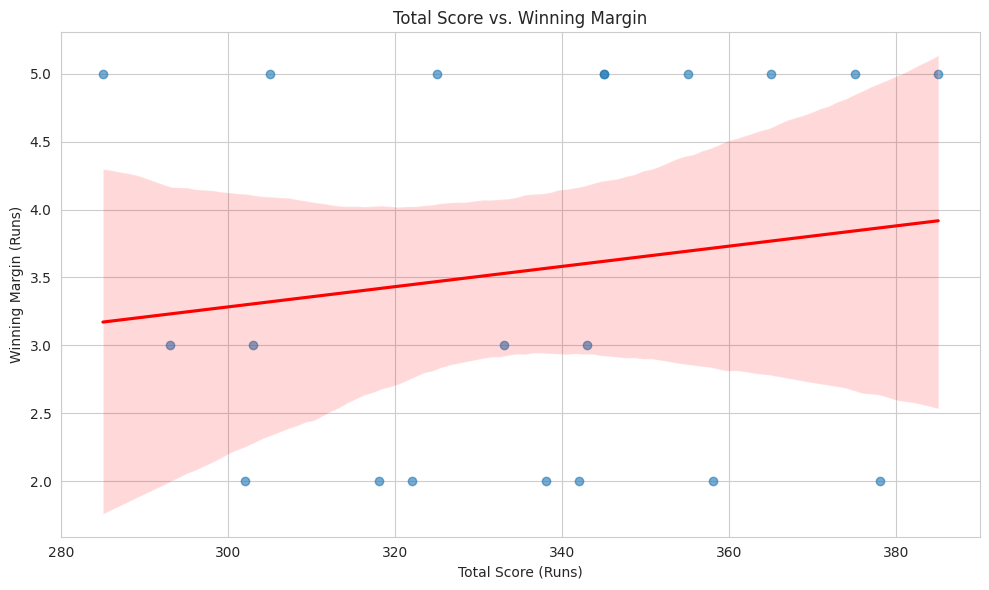

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Total_Score', y='Winning_Margin', data=df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Total Score vs. Winning Margin')
plt.xlabel('Total Score (Runs)')
plt.ylabel('Winning Margin (Runs)')
plt.tight_layout()
plt.show()